In [1]:
# CELL 1: Imports
import os
os.environ['TQDM_NOTEBOOK'] = '1'

import importlib
import numpy as np
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
%matplotlib inline

import config, matrices, newton_solver, time_stepping, io_utils, convergence
importlib.reload(config)
importlib.reload(matrices)
importlib.reload(newton_solver)
importlib.reload(time_stepping)
importlib.reload(io_utils)
importlib.reload(convergence)

VCNLSConfig     = config.VCNLSConfig
VCNLSMatrices   = matrices.VCNLSMatrices
NewtonSolver    = newton_solver.NewtonSolver
VCNLSIntegrator = time_stepping.VCNLSIntegrator
VCNLSVisualizer = io_utils.VCNLSVisualizer
temporal_convergence = convergence.temporal_convergence
spatial_convergence  = convergence.spatial_convergence

print('Modules loaded OK')

Modules loaded OK


In [2]:

# CELL 2: Configuration and Simulation
alpha = 1.0
v = 1.0

cfg = VCNLSConfig(
    xL=-20.0, xR=20.0, N=8000, T=3.0, k=0.01,
    a=lambda t: 0.5,          
    d=lambda t: 0.0,
    g=lambda t: 0.0,
    h_coeff=lambda t: -1.0,    # h(t) = 1
    epsilon=1e-10, max_iter=32, save_every=1, verbose=True
)

# Solución exacta: Ψ(x,t) = α·sech(2α(x−vt))·exp[i(vx−(2v²−α)t)]
def epsi(x, t):
    return np.sqrt(alpha) * (1.0 / np.cosh(np.sqrt(2 * alpha) * (x - v * t))) * np.exp(1j * (v * x - ((v**2)/2 - alpha) * t))

# Condiciones iniciales en t=0
psi0 = lambda x: epsi(x, 0.0)
phi0 = lambda x: -1*epsi(x,0.0)   # φ=0 si solo hay una componente

integrator = VCNLSIntegrator(cfg, use_gpu=True) 
V0 = integrator.set_initial_condition(psi0, phi0)
result = integrator.integrate(V0)

Integrating:   0%|          | 0/300 [00:00<?, ?step/s]

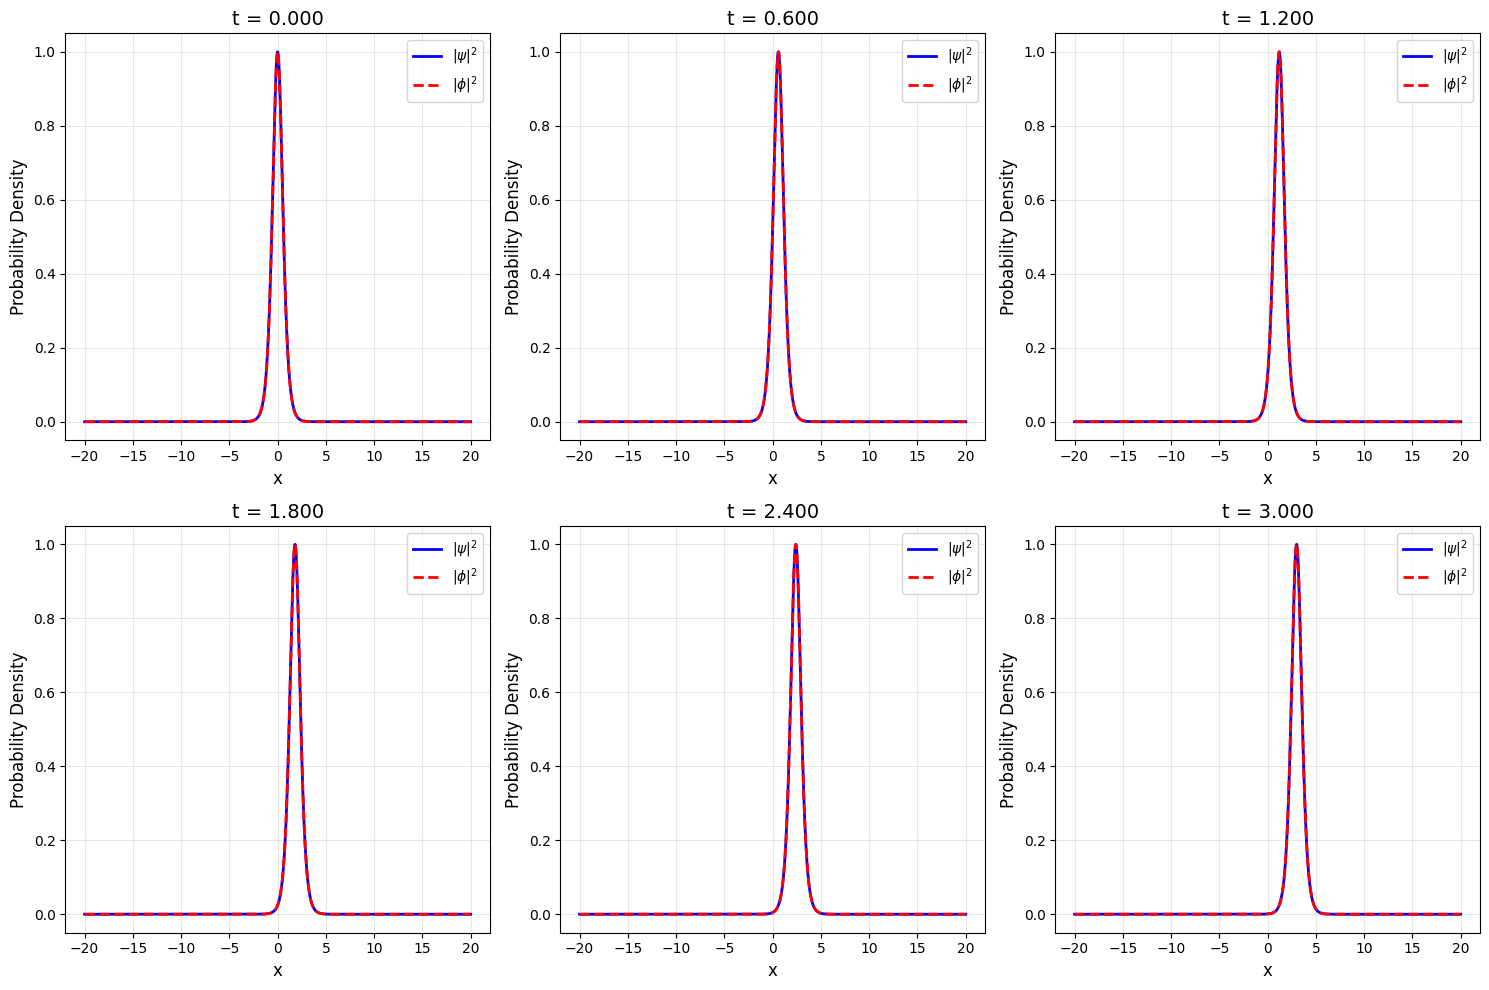

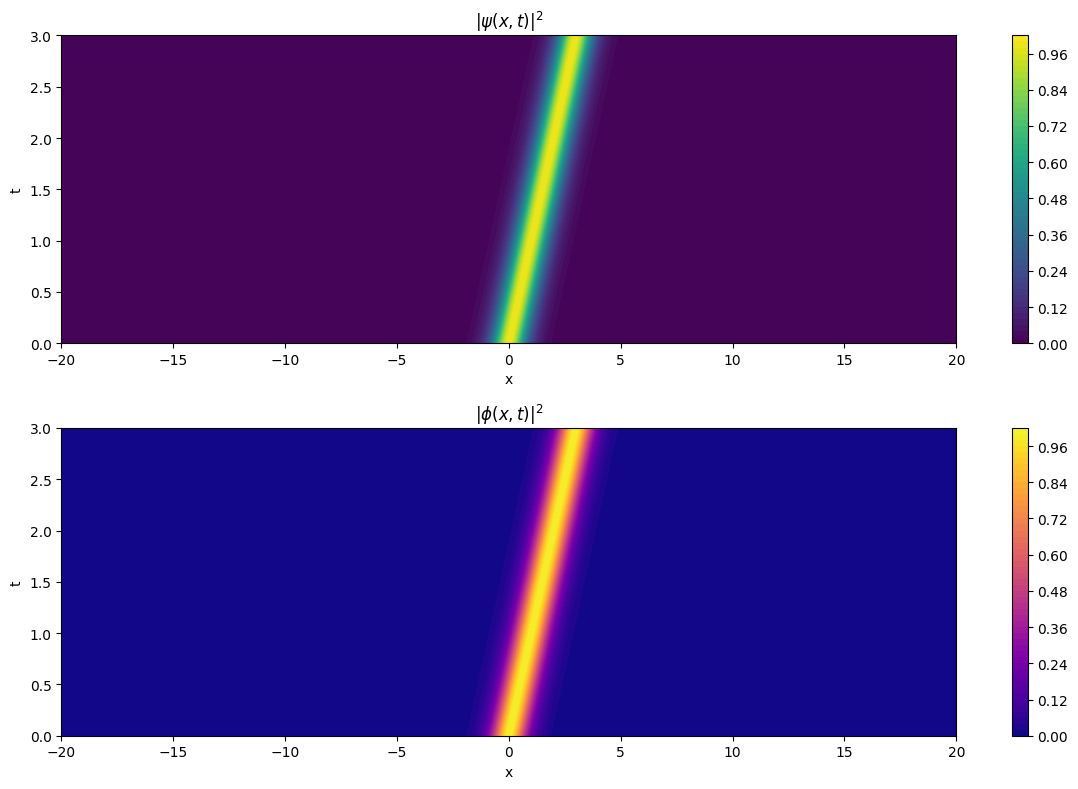

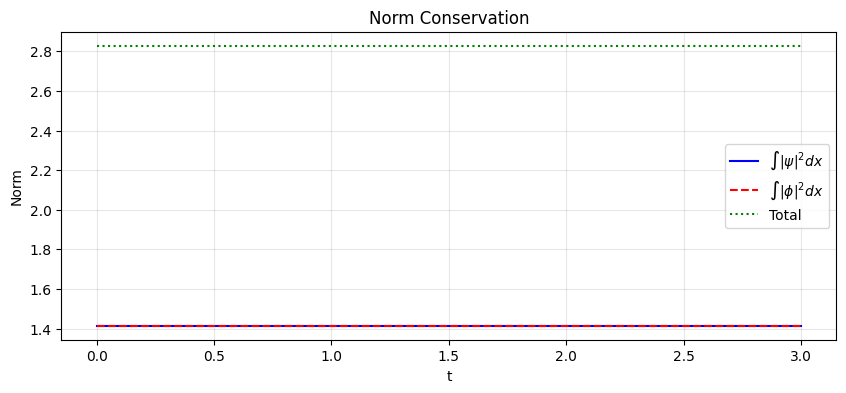

Variation: 7.93e-09


In [3]:
# CELL 3: Visualization
times = result['times']
states = result['states']
x = result['x_grid']

psi, phi = VCNLSVisualizer.reconstruct_wavefunctions(states, cfg.n_nodes)

# Evolution plot
fig1 = VCNLSVisualizer.plot_evolution(x, times, phi, psi)
plt.show()

# Heatmap
fig2 = VCNLSVisualizer.plot_amplitude_map(x, times, psi, phi)
plt.show()

# Conservation check
norms_psi = np.trapezoid(np.abs(psi)**2, x, axis=1)
norms_phi = np.trapezoid(np.abs(phi)**2, x, axis=1)

fig3, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, norms_psi, 'b-', label=r'$\int|\psi|^2dx$')
ax.plot(times, norms_phi, 'r--', label=r'$\int|\phi|^2dx$')
ax.plot(times, norms_psi + norms_phi, 'g:', label=r'Total')
ax.set_xlabel('t'); ax.set_ylabel('Norm'); ax.set_title('Norm Conservation')
ax.legend(); ax.grid(True, alpha=0.3); plt.show()

print(f"Variation: {abs(norms_psi[-1] + norms_phi[-1] - norms_psi[0] - norms_phi[0]):.2e}")

0.0002895482383985375
3.562422044639524e-05


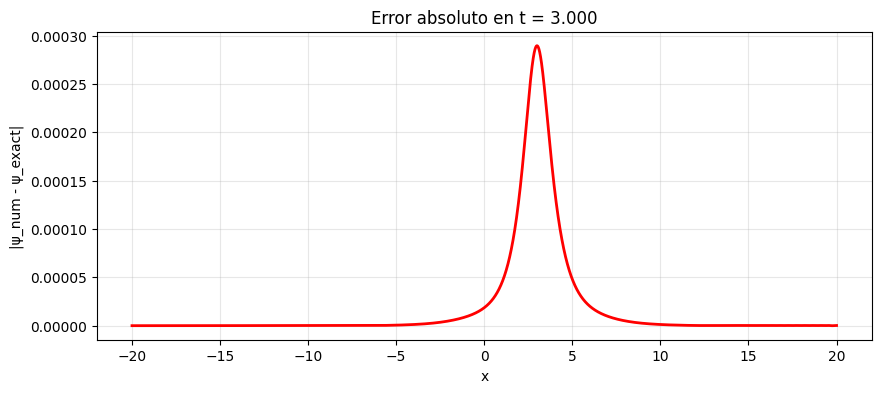

In [4]:
# Error punto a punto en el tiempo final

psi_exact_final = epsi(x,times[-1])
error_abs = np.abs(psi[-1] - psi_exact_final)
print(np.max(error_abs))
infinitenorm = np.max(np.abs(psi[-1]) - np.abs(epsi(x,times[-1])))
print(infinitenorm)

# Graficar
plt.figure(figsize=(10,4))
plt.plot(x, error_abs, 'r-', linewidth=2)
plt.xlabel('x'); plt.ylabel('|ψ_num - ψ_exact|')
plt.title(f'Error absoluto en t = {times[-1]:.3f}')
plt.grid(True, alpha=0.3)
plt.show()

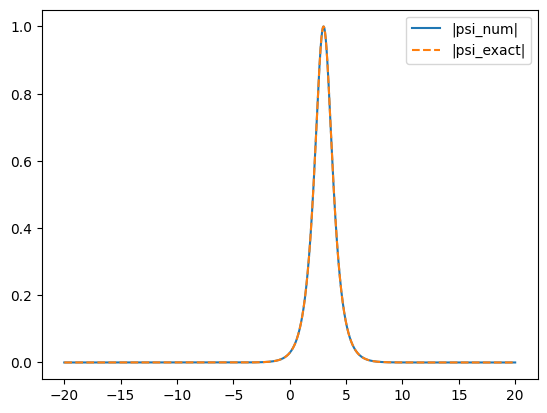

In [5]:
plt.plot(x, np.abs(psi[-1]), label='|psi_num|')
plt.plot(x, np.abs(psi_exact_final), '--', label='|psi_exact|')
plt.legend()
plt.show()

In [8]:
cfg_time = VCNLSConfig(
    xL=-20.0, xR=20.0,
    N=8000,          # h ≈ 0.001, spatial error negligible
    T=4.0,
    k=0.01,            # placeholder, overridden per run
    a=lambda t: 0.5,
    d=lambda t: 0.0,
    g=lambda t: 0.0,
    h_coeff=lambda t: -1.0,
    epsilon=1e-12, max_iter=30,
)

df_time = temporal_convergence(cfg_time, epsi,
                               k_list=[0.2, 0.1, 0.05, 0.025],
                               use_gpu=True)


TEMPORAL CONVERGENCE ANALYSIS
  Fixed spatial intervals : N = 8000  (h = 0.00500)
  Time steps tested       : [0.2, 0.1, 0.05, 0.025]
  Final time              : T = 4.0
  Newton tolerance        : 1e-12
  GPU acceleration        : True



Temporal convergence:   0%|          | 0/4 [00:00<?, ?run/s]


TEMPORAL CONVERGENCE TABLE
     Delta_t  L_inf_Error        Order
2.000000e-01 1.096782e-01          NaN
1.000000e-01 2.891750e-02 1.923262e+00
5.000000e-02 7.398005e-03 1.966735e+00
2.500000e-02 1.928628e-03 1.939561e+00

